In [3]:
# %pip install shap

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import joblib
import shap
import catboost
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

print(f"Using CatBoost version: {catboost.__version__}")
print(f"Using SHAP version: {shap.__version__}")

Using CatBoost version: 1.2.8
Using SHAP version: 0.48.0


In [ ]:
# --- 1. CONFIGURATION: UPDATE THESE FILENAMES ---
# ------------------------------------------------------------------------------

# Example: 'weights/final_catboost_model_20250622_162350.cbm'
MODEL_FILE_TO_LOAD = 'weights/final_catboost_model_20250622_174142.cbm' 

# Example: 'weights/preprocessor_20250622_162350.joblib'
PREPROCESSOR_FILE_TO_LOAD = 'weights/preprocessor_20250622_174142.joblib'

# Directory to save the output plots
PLOTS_DIR = './shap_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

In [7]:
# --- 2. DATA LOADING & PREPARATION ---
# ------------------------------------------------------------------------------
# This section reloads the original data to get access to the test set (X_test)
# which is used to generate the explanations.
# NOTE: This assumes you have access to the original `data_pipeline.py` file
# or can replicate its data loading logic.
try:
    # This import is from your original notebook.
    # Make sure the 'pipeline' directory is accessible from where you run this script.
    from pipeline.data_pipeline import preprocessor, X, y
    print("Successfully loaded data from 'pipeline.data_pipeline'.")
    
    # Isolate the 'damage' column and drop it, just like in the training notebook
    if 'damage' in X.columns:
        damage_series = X['damage'].copy()
        X = X.drop(columns=['damage'])
    else:
        damage_series = pd.Series(0, index=X.index) # Create a dummy if not present

    # Recreate the exact same train/test split to get the correct X_test
    X_train, X_test, y_train, y_test, damage_train, damage_test = train_test_split(
        X, y, damage_series, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Data split successfully. X_test has {X_test.shape[0]} samples.")

except ImportError:
    print("Error: Could not import from 'pipeline.data_pipeline'.")
    print("Please ensure this script is run from a location where it can find the 'pipeline' directory.")
    print("As a fallback, creating dummy data to allow the script to run.")
    # Create dummy data if the import fails, so the rest of the script can be checked.
    X_test = pd.DataFrame({f'feature_{i}': range(10) for i in range(20)})
    y_test = pd.Series([0,1]*5)

Successfully loaded data from 'pipeline.data_pipeline'.
Data split successfully. X_test has 31139 samples.


In [10]:
# --- 3. LOAD THE TRAINED MODEL AND PREPROCESSOR ---
# ------------------------------------------------------------------------------
try:
    # Load the preprocessor object
    loaded_preprocessor = joblib.load(PREPROCESSOR_FILE_TO_LOAD)
    print(f"Preprocessor loaded successfully from: {PREPROCESSOR_FILE_TO_LOAD}")

    # Load the CatBoost model
    loaded_model = catboost.CatBoostClassifier()
    loaded_model.load_model(MODEL_FILE_TO_LOAD)
    print(f"Model loaded successfully from: {MODEL_FILE_TO_LOAD}")

    # Preprocess the test data using the *loaded* preprocessor
    # This is crucial for consistency.
    X_test_prep = loaded_preprocessor.transform(X_test)
    
    # --- FIX ---
    # Get the correct feature names from the preprocessor after it has been fitted.
    # This is crucial as one-hot encoding expands the number of features.
    try:
        # This works for scikit-learn >= 1.0
        new_column_names = loaded_preprocessor.get_feature_names_out()
    except AttributeError:
        # Fallback for older scikit-learn versions
        print("Warning: .get_feature_names_out() not available. Using a generic fallback.")
        # This part might need adjustment if your preprocessor isn't a ColumnTransformer
        new_column_names = [f'feature_{i}' for i in range(X_test_prep.shape[1])]

    # The SHAP library works best with pandas DataFrames. We convert the numpy array
    # back to a DataFrame using the new, correct feature names for better plot labels.
    X_test_prep_df = pd.DataFrame(X_test_prep, columns=new_column_names, index=X_test.index)

except FileNotFoundError:
    print("-" * 50)
    print(f"ERROR: File not found. Please check your filenames and paths.")
    print(f"Attempted to load model: {MODEL_FILE_TO_LOAD}")
    print(f"Attempted to load preprocessor: {PREPROCESSOR_FILE_TO_LOAD}")
    print("Exiting script.")
    exit()

Preprocessor loaded successfully from: weights/preprocessor_20250622_174142.joblib
Model loaded successfully from: weights/final_catboost_model_20250622_174142.cbm


In [8]:
# # --- 3. LOAD THE TRAINED MODEL AND PREPROCESSOR ---
# # ------------------------------------------------------------------------------
# try:
#     # Load the preprocessor object
#     loaded_preprocessor = joblib.load(PREPROCESSOR_FILE_TO_LOAD)
#     print(f"Preprocessor loaded successfully from: {PREPROCESSOR_FILE_TO_LOAD}")

#     # Load the CatBoost model
#     loaded_model = catboost.CatBoostClassifier()
#     loaded_model.load_model(MODEL_FILE_TO_LOAD)
#     print(f"Model loaded successfully from: {MODEL_FILE_TO_LOAD}")

#     # Preprocess the test data using the *loaded* preprocessor
#     # This is crucial for consistency.
#     X_test_prep = loaded_preprocessor.transform(X_test)
#     # The SHAP library works best with pandas DataFrames, so we convert it back
#     # and use the original feature names for better plot labels.
#     X_test_prep_df = pd.DataFrame(X_test_prep, columns=X_test.columns)

# except FileNotFoundError:
#     print("-" * 50)
#     print(f"ERROR: File not found. Please check your filenames and paths.")
#     print(f"Attempted to load model: {MODEL_FILE_TO_LOAD}")
#     print(f"Attempted to load preprocessor: {PREPROCESSOR_FILE_TO_LOAD}")
#     print("Exiting script.")
#     exit()

Preprocessor loaded successfully from: weights/preprocessor_20250622_174142.joblib
Model loaded successfully from: weights/final_catboost_model_20250622_174142.cbm


ValueError: Shape of passed values is (31139, 62), indices imply (31139, 15)

In [14]:
# --- 4. CALCULATE SHAP VALUES ---
# ------------------------------------------------------------------------------
print("\nCalculating SHAP values... This may take a moment.")

# Create a SHAP TreeExplainer object with the loaded model
explainer = shap.TreeExplainer(loaded_model)

# Calculate the SHAP values for the preprocessed test set
shap_values_output = explainer.shap_values(X_test_prep_df)

# --- FIX for AssertionError ---
# The explainer can return a list of two arrays (one for each class) or a single
# array for the positive class. We need to handle both cases to avoid errors.
if isinstance(shap_values_output, list):
    # This is the typical case for binary classification (output for class 0 and class 1)
    shap_values_for_plotting = shap_values_output[1]
    print("SHAP explainer returned a list of arrays. Selected values for the positive class (FRAUD).")
else:
    # This can happen with some model/library versions where only the positive class values are returned
    shap_values_for_plotting = shap_values_output
    print("SHAP explainer returned a single array.")

# Final check to ensure we have a 2D matrix for plotting
assert len(shap_values_for_plotting.shape) == 2, "SHAP values for plotting must be a 2D array (matrix)."

print("SHAP values calculated and validated successfully.")


Calculating SHAP values... This may take a moment.
SHAP explainer returned a single array.
SHAP values calculated and validated successfully.


In [15]:
# --- 5. GENERATE AND SAVE SHAP PLOTS ---
# ------------------------------------------------------------------------------

# -- Plot 1: Global Feature Importance (Summary Plot) --
# This plot shows the most important features and the distribution of their SHAP values.
print("\nGenerating SHAP summary plot...")
plt.figure()
# Use the robustly determined shap_values_for_plotting variable
shap.summary_plot(shap_values_for_plotting, X_test_prep_df, show=False)
plt.title("Global Feature Importance (SHAP Summary)", fontsize=14)
plt.tight_layout()
summary_plot_path = os.path.join(PLOTS_DIR, 'shap_summary_plot.png')
plt.savefig(summary_plot_path)
plt.close() # Close the plot to free up memory
print(f"Summary plot saved to: {summary_plot_path}")


# -- Plot 2: Local Explanation for a Single Prediction (Force Plot) --
# This plot explains a single instance. We will find a true positive (a correctly
# identified FRAUD case) to make the explanation more interesting.

# Find the index of the first true positive case in the test set, if one exists
y_pred = loaded_model.predict(X_test_prep)
true_positives = X_test[(y_test == 1) & (y_pred == 1)]

if not true_positives.empty:
    idx_to_explain = true_positives.index[0]
    print(f"\nGenerating Force Plot for a true positive case (index: {idx_to_explain})...")
else:
    idx_to_explain = X_test.index[0] # Fallback to the first sample if no TP found
    print(f"\nNo true positive case found in test set. Generating Force Plot for the first sample (index: {idx_to_explain})...")

# The force plot requires the base value (expected value) from the explainer.
# This can also be a list or a single value, so we handle both cases.
base_value = explainer.expected_value
if isinstance(base_value, list):
    base_value = base_value[1] # Select base value for the "FRAUD" class

# Get the integer position of the index for .iloc/.loc access
loc_of_idx = X_test.index.get_loc(idx_to_explain)

# Generate the force plot for the selected instance
force_plot = shap.force_plot(
    base_value, 
    shap_values_for_plotting[loc_of_idx], # Use the robust variable here as well
    X_test_prep_df.iloc[loc_of_idx],
    matplotlib=True, # Use matplotlib for saving
    show=False
)

force_plot_path = os.path.join(PLOTS_DIR, f'shap_force_plot_instance_{idx_to_explain}.png')
plt.savefig(force_plot_path, bbox_inches='tight') # Add bbox_inches for better layout
plt.close()
print(f"Force plot saved to: {force_plot_path}")

print("\nScript finished.")


Generating SHAP summary plot...
Summary plot saved to: ./shap_plots\shap_summary_plot.png

Generating Force Plot for a true positive case (index: 120860)...
Force plot saved to: ./shap_plots\shap_force_plot_instance_120860.png

Script finished.


Initialisiere SHAP für die Visualisierung im Notebook...



Anzeige des SHAP Summary Plots (Globale Feature-Wichtigkeit):


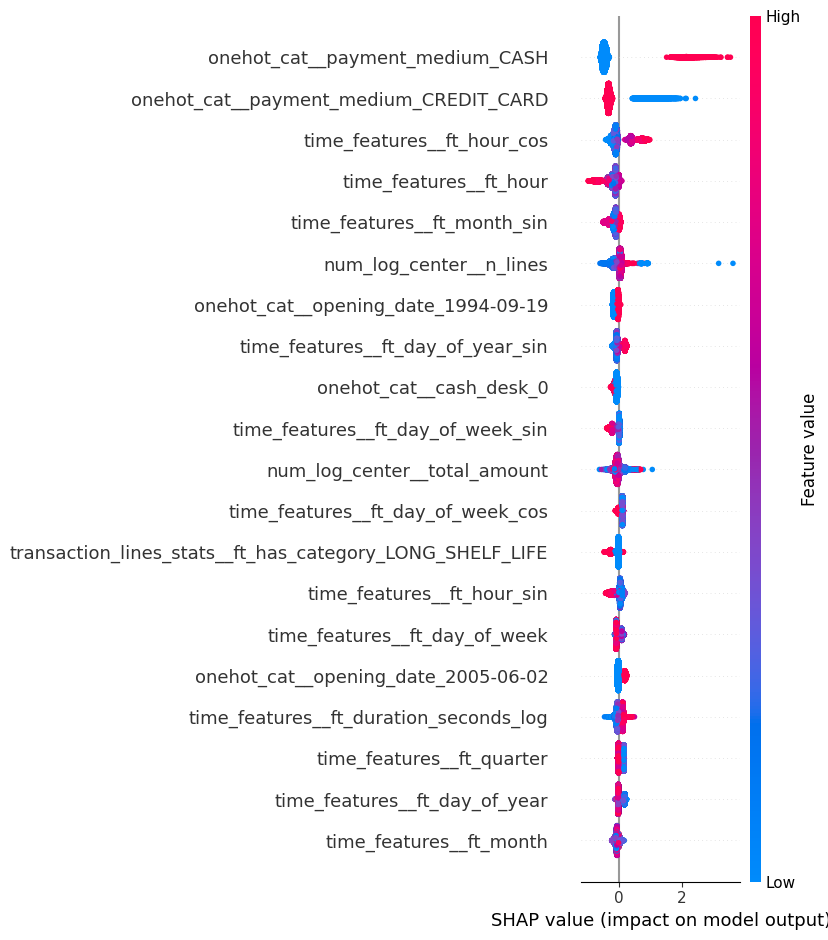


Analyse einer einzelnen Transaktion (Index: 120860), die korrekt als 'FRAUD' erkannt wurde.

Anzeige des interaktiven SHAP Force Plots (Erklärung einer einzelnen Vorhersage):


In [16]:
# ==============================================================================
# 5. Visualisierung der SHAP-Werte im Notebook
# ==============================================================================
# Wichtig: Führen Sie diese Zelle erst aus, nachdem die vorherigen Zellen 
# (Daten laden, Modell laden, SHAP-Werte berechnen) gelaufen sind.

print("Initialisiere SHAP für die Visualisierung im Notebook...")
# Diese Funktion lädt die notwendigen JavaScript-Bibliotheken in Ihr Notebook.
shap.initjs()


# --- Plot 1: Global Feature Importance (Summary Plot) ---
# ------------------------------------------------------------------------------
# Dieser Plot wird direkt unter der Zelle angezeigt.
# - Jede Zeile ist eine Eigenschaft (Feature).
# - Jeder Punkt ist eine einzelne Vorhersage aus dem Testset.
# - Die Farbe zeigt den Wert des Features für diese Vorhersage an (Rot = hoch, Blau = niedrig).
# - Die Position auf der X-Achse zeigt, wie stark dieses Feature die Vorhersage
#   in Richtung "FRAUD" (positive Werte) oder "NORMAL" (negative Werte) gedrückt hat.

print("\nAnzeige des SHAP Summary Plots (Globale Feature-Wichtigkeit):")
shap.summary_plot(shap_values_for_plotting, X_test_prep_df, plot_type="dot")


# --- Plot 2: Lokale Erklärung für eine einzelne Vorhersage (Force Plot) ---
# ------------------------------------------------------------------------------
# Wir suchen wieder eine korrekt als "FRAUD" erkannte Transaktion, um sie zu analysieren.

y_pred = loaded_model.predict(X_test_prep)
true_positives = X_test[(y_test == 1) & (y_pred == 1)]

if not true_positives.empty:
    idx_to_explain = true_positives.index[0]
    print(f"\nAnalyse einer einzelnen Transaktion (Index: {idx_to_explain}), die korrekt als 'FRAUD' erkannt wurde.")
else:
    idx_to_explain = X_test.index[0] # Fallback
    print(f"\nKein 'True Positive' gefunden. Analyse der ersten Transaktion im Testset (Index: {idx_to_explain}).")

# Integer-Position des Index für die Daten-Selektion holen
loc_of_idx = X_test.index.get_loc(idx_to_explain)

# Basiswert des Explainers (Durchschnittliche Vorhersage)
base_value = explainer.expected_value
if isinstance(base_value, list):
    base_value = base_value[1]

print("\nAnzeige des interaktiven SHAP Force Plots (Erklärung einer einzelnen Vorhersage):")
# Diese Funktion erzeugt einen interaktiven Plot.
# - "base value" ist die durchschnittliche Vorhersagewahrscheinlichkeit über das ganze Dataset.
# - Rote Features (wie "sum_total_transactions") erhöhen die Wahrscheinlichkeit für "FRAUD".
# - Blaue Features senken die Wahrscheinlichkeit.
# - Die Länge der Blöcke zeigt die Stärke des Einflusses.
# - "f(x)" ist die finale Vorhersage für diese eine Transaktion.
shap.force_plot(
    base_value, 
    shap_values_for_plotting[loc_of_idx], 
    X_test_prep_df.iloc[loc_of_idx]
)

In [20]:
# ==============================================================================
# 6. Speichern der SHAP-Plots als Dateien
# ==============================================================================
import matplotlib.pyplot as plt
from datetime import datetime
import os

print("Speichere SHAP-Visualisierungen als PNG-Dateien...")

# --- Vorbereitung ---
# Ordner für die Plots definieren und erstellen, falls er nicht existiert
plots_dir = './shap_plots'
os.makedirs(plots_dir, exist_ok=True)

# Zeitstempel für eindeutige Dateinamen erstellen
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")


# --- Plot 1: Summary Plot als PNG speichern ---
# ------------------------------------------------------------------------------
# Wir erstellen die Figur neu, um sicherzustellen, dass sie die richtige Größe hat
# und sauber gespeichert wird, ohne die vorherige Anzeige zu beeinflussen.
plt.figure(figsize=(10, 8)) 
shap.summary_plot(shap_values_for_plotting, X_test_prep_df, show=False)
plt.title("Global Feature Importance (SHAP Summary)", fontsize=14)

summary_plot_path = os.path.join(plots_dir, f'shap_summary_plot_{timestamp}.png')

# bbox_inches='tight' stellt sicher, dass alle Elemente (Titel, Achsenbeschriftungen)
# in das gespeicherte Bild passen und nichts abgeschnitten wird.
plt.savefig(summary_plot_path, dpi=150, bbox_inches='tight') 
plt.close() # Schließt die Figur, um Speicher freizugeben

print(f"Summary Plot gespeichert unter: {summary_plot_path}")


# --- Plot 2: Force Plot als PNG speichern ---
# ------------------------------------------------------------------------------
# Um den Force Plot zu speichern, MÜSSEN wir ihn mit matplotlib rendern.

# --- FIX ---
# Wir wenden einen mehrstufigen Fix an, um die überlappenden Namen zu beheben:
# 1. Wir zeichnen den Plot und fügen eine leichte Textrotation hinzu.
# 2. Wir holen uns die aktuelle Matplotlib-Figur (gcf = get current figure).
# 3. Wir setzen die Größe dieser Figur manuell auf ein breites Format.

shap.force_plot(
    base_value, 
    shap_values_for_plotting[loc_of_idx], 
    X_test_prep_df.iloc[loc_of_idx],
    matplotlib=True, 
    show=False,
    text_rotation=15  # NEU: Rotiert die Feature-Namen leicht
)

# Holen Sie sich die aktuelle Figur, nachdem sie von SHAP gezeichnet wurde
fig = plt.gcf()
# Setzen Sie die Breite der Figur auf einen großen Wert
fig.set_figwidth(20)

force_plot_path = os.path.join(plots_dir, f'shap_force_plot_instance_{idx_to_explain}_{timestamp}.png')
# bbox_inches='tight' ist hier besonders wichtig, damit nichts abgeschnitten wird.
plt.savefig(force_plot_path, bbox_inches='tight', dpi=150)
plt.close()

print(f"Force Plot gespeichert unter: {force_plot_path}")
print("\nSpeichern der Plots abgeschlossen.")


Speichere SHAP-Visualisierungen als PNG-Dateien...
Summary Plot gespeichert unter: ./shap_plots\shap_summary_plot_20250622_182931.png
Force Plot gespeichert unter: ./shap_plots\shap_force_plot_instance_120860_20250622_182931.png

Speichern der Plots abgeschlossen.


In [21]:
# ==============================================================================
# 7. Text-Ausgabe der SHAP-Werte für eine einzelne Vorhersage
# ==============================================================================
# Diese Zelle gibt die SHAP-Werte für dieselbe Transaktion, die wir zuvor
# im Force Plot analysiert haben, als reine Text-Liste aus.

print(f"--- Analyse der SHAP-Werte für Transaktion mit Index: {idx_to_explain} ---\n")

# Extrahieren der benötigten Daten für die ausgewählte Instanz
shap_values_instance = shap_values_for_plotting[loc_of_idx]
feature_values_instance = X_test_prep_df.iloc[loc_of_idx]
feature_names = X_test_prep_df.columns

# Kombinieren der Daten in einer Liste von Dictionaries, um sie leicht sortieren zu können
feature_impacts = []
for i, feature_name in enumerate(feature_names):
    feature_impacts.append({
        "feature": feature_name,
        "shap_value": shap_values_instance[i],
        "feature_value": feature_values_instance[i]
    })

# Sortieren der Features nach dem absoluten Betrag ihres SHAP-Wertes (von hoch nach niedrig)
# So stehen die einflussreichsten Features ganz oben.
feature_impacts_sorted = sorted(feature_impacts, key=lambda x: abs(x['shap_value']), reverse=True)


# Ausgabe der Header-Informationen
print(f"Durchschnittliche Modellvorhersage (Base Value): {base_value:.4f}")
# Die finale Vorhersage ist die Summe aus dem Basiswert und allen einzelnen SHAP-Werten
final_prediction_score = base_value + sum(shap_values_instance)
print(f"Finale Modellvorhersage (Log-Odds) für diesen Fall: {final_prediction_score:.4f}\n")
print("Features geordnet nach ihrem Einfluss auf die Vorhersage (Top 20):\n")

# Ausgabe der 20 einflussreichsten Features in einem sauberen Format
for impact in feature_impacts_sorted[:20]:
    # Wir formatieren den SHAP-Wert, um immer ein Vorzeichen anzuzeigen (+ oder -)
    shap_str = f"{impact['shap_value']:+.4f}"
    
    # Wir formatieren den Feature-Wert, um ihn leserlich zu machen
    try:
        feature_val_str = f"{float(impact['feature_value']):.2f}"
    except (ValueError, TypeError):
        feature_val_str = str(impact['feature_value'])
        
    print(f"Feature: {impact['feature']:<45} | SHAP-Wert: {shap_str:<12} | Wert des Features: {feature_val_str}")

--- Analyse der SHAP-Werte für Transaktion mit Index: 120860 ---

Durchschnittliche Modellvorhersage (Base Value): -2.4188
Finale Modellvorhersage (Log-Odds) für diesen Fall: 2.7421

Features geordnet nach ihrem Einfluss auf die Vorhersage (Top 20):

Feature: transaction_lines_stats__ft_has_category_SNACKS | SHAP-Wert: +2.7961      | Wert des Features: 1.00
Feature: num_log_center__n_lines                       | SHAP-Wert: +0.9153      | Wert des Features: -1.39
Feature: time_features__ft_hour_cos                    | SHAP-Wert: +0.5938      | Wert des Features: 1.69
Feature: time_features__ft_hour                        | SHAP-Wert: -0.5167      | Wert des Features: 1.37
Feature: num_log_center__total_amount                  | SHAP-Wert: +0.5139      | Wert des Features: -3.66
Feature: onehot_cat__payment_medium_CASH               | SHAP-Wert: -0.4188      | Wert des Features: 0.00
Feature: transaction_lines_stats__ft_avg_line_price    | SHAP-Wert: +0.3767      | Wert des Features: 0

C:\Users\lol--\AppData\Local\Temp\ipykernel_2324\1089516829.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "feature_value": feature_values_instance[i]
